# Diversity sustained by new clones

In [2]:
import numpy as np
import pyrepseq as prs
import matplotlib as mpl

from scipy.stats import gumbel_r

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import repertoire_simulator.lib as lib
import repertoire_simulator.how_to_maintain_diversity.lib as lib_div


plt.style.use("../../project_style.mplstyle")
%config InlineBackend.figure_format = 'retina'

DATA_PATH = "../../data/"

/Users/james/Documents/Projects/repertoire_sims_2026/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Analysis for $\alpha = 1.2$

In [3]:
ratios = np.logspace(1, 5.5, 10)
results_for_ratio = {}
cs_final_for_ratio = {}
cmaxes_for_ratio = {}
for ratio in ratios:
    records = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/alpha_1.2/ratio_{ratio}.npz", allow_pickle=True)
    t = records['t']
    c_t = records['c']
    Seff = np.zeros(len(t))
    T = np.zeros(len(t))
    S = np.zeros(len(t))
    cmax = np.zeros(len(t))
    
    cs_final_for_ratio[ratio] = c_t[-1]
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        T[i] = np.mean(c_t[i].sum(axis=0))
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        cmax[i] = np.max(c_t[i])
        
    results_for_ratio[ratio] = {'t':t, 'Seff':Seff, 'T':T, 'S':S, 'cmax':cmax}

### Clone size distribution

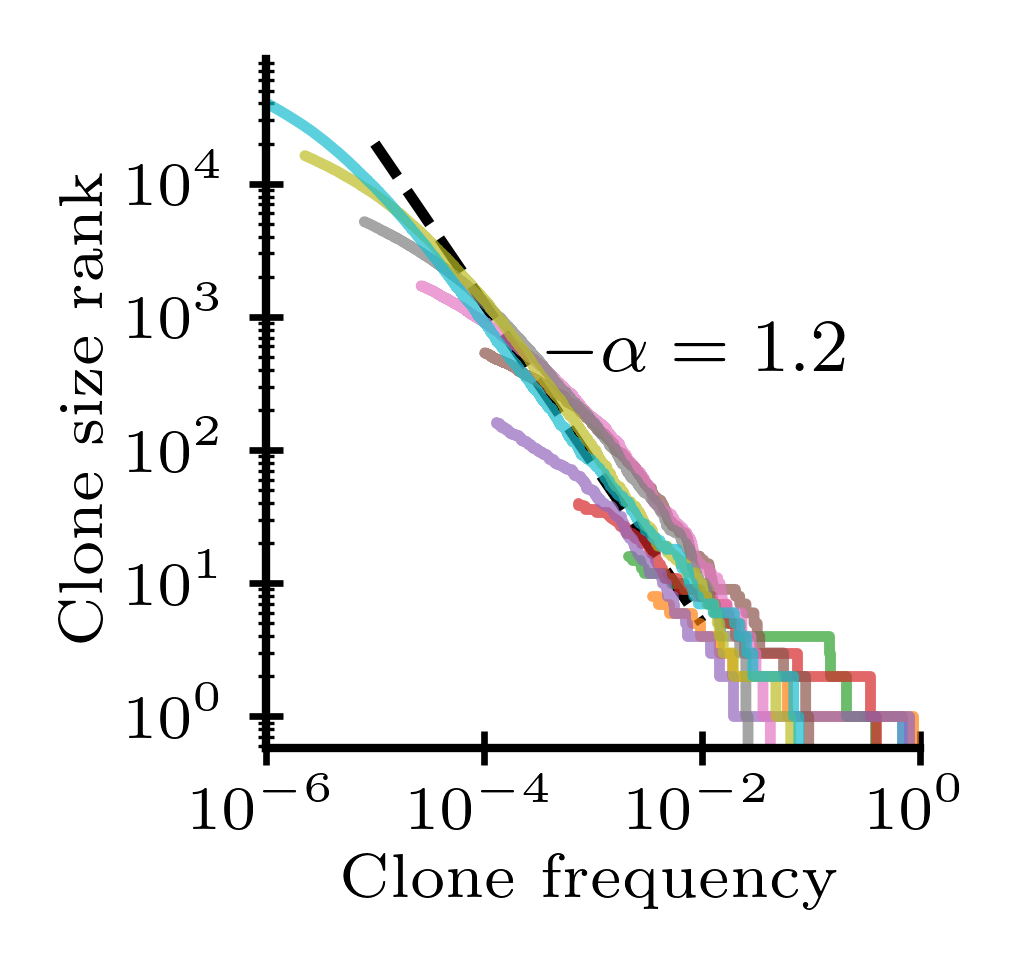

In [4]:
fig, ax = plt.subplots(figsize=(1.6, 1.5), layout='constrained')
lib.plot_referencescaling(ax=ax, x=[1e-5, 1e-2], factor=2e-2, exponent=-1.2, linestyle='--')
for ratio in ratios:
    c = cs_final_for_ratio[ratio]
    prs.plotting.rankfrequency(c[c >= 1], ax=ax, normalize_x=True, alpha=0.7)
ax.set_xlim([1e-6, 1e0]);

### Scaling of $S_{\mathrm{eff}}$

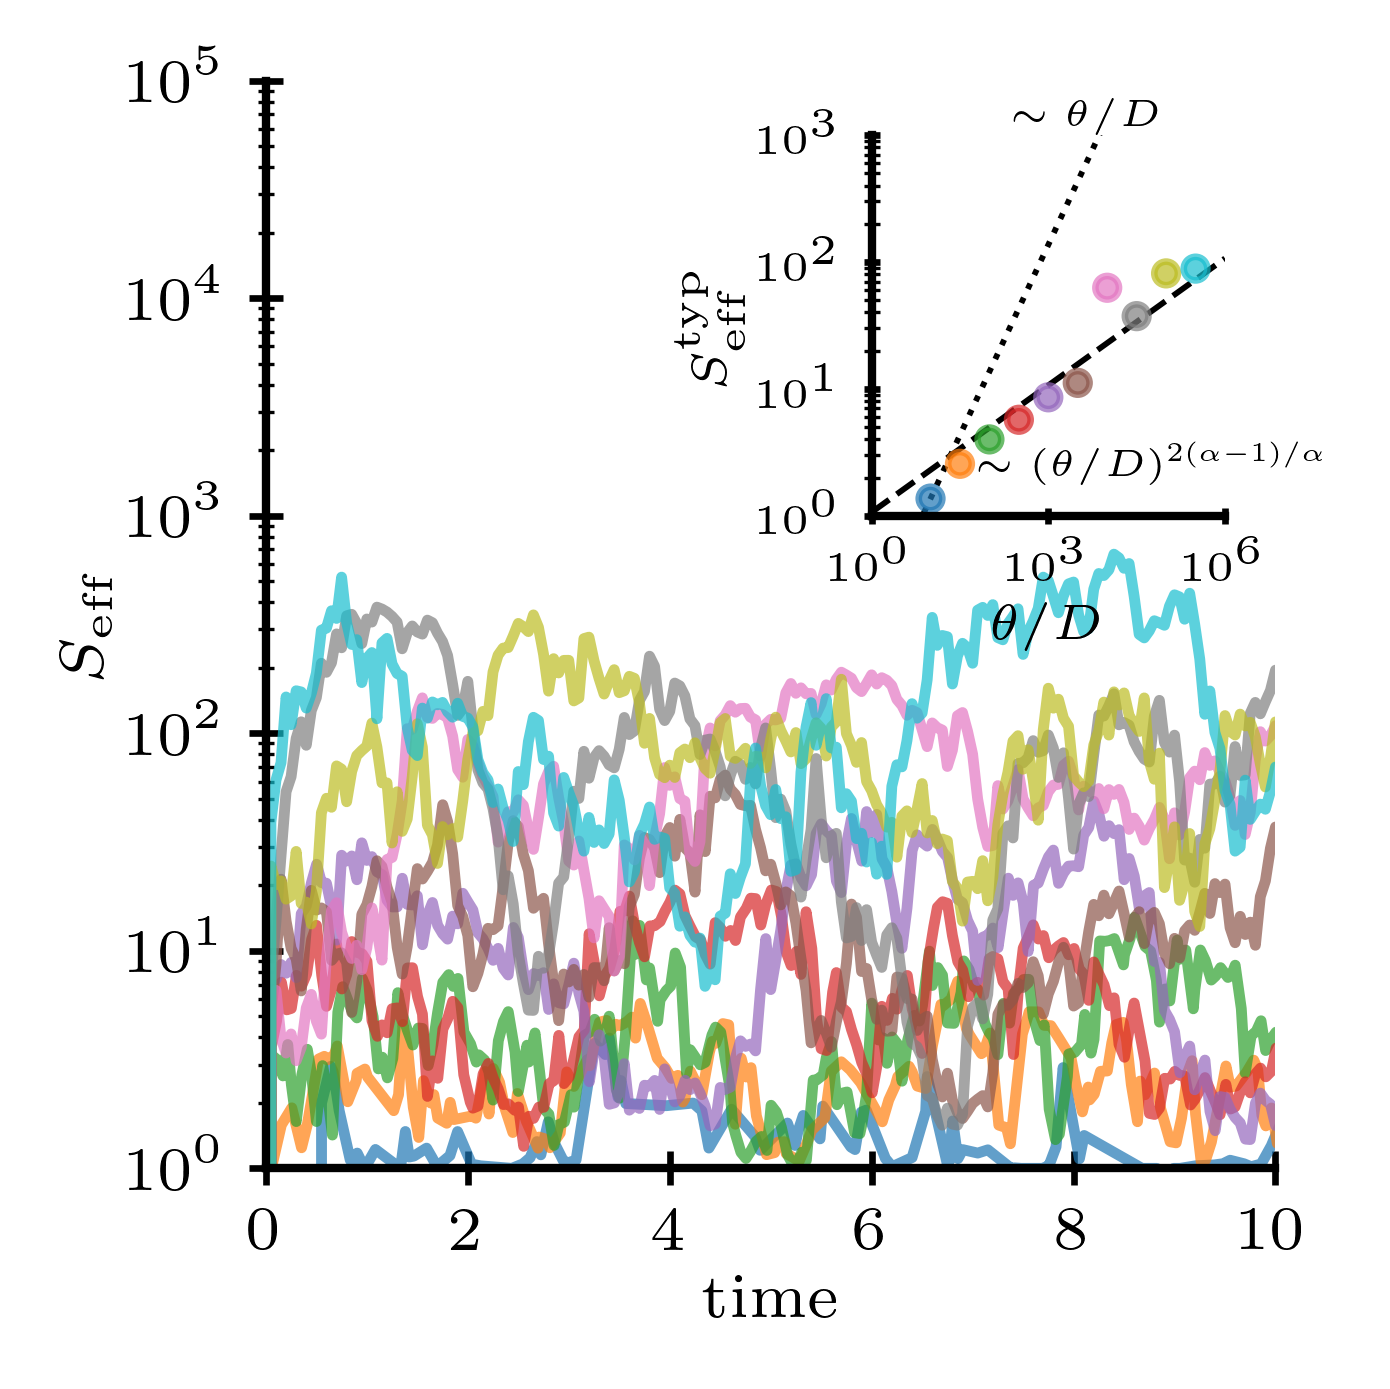

In [6]:
fig, ax = plt.subplots(figsize=(2.2, 2.2), layout='constrained')

alpha = 1.2
typical_diversities = []
colors = []
for ratio in ratios:
    t =  results_for_ratio[ratio]['t']
    
    Seff =  results_for_ratio[ratio]['Seff']
    line, = ax.plot(t, Seff, alpha=0.7)
    colors.append(line.get_color())    
    
    typical_Seff = lib.geometric_mean_after_burn(Seff)
    typical_diversities.append(typical_Seff)

ax.set_yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1, 1e5)
ax.set_xlabel(r'time')
ax.set_ylabel(r'$S_{\mathrm{eff}}$')

inset = ax.inset_axes([0.6, 0.6, 0.35, 0.35])
inset.scatter(ratios, typical_diversities, s=8, c=np.asarray(colors), alpha=0.7)
inset.set_xscale('log')
inset.set_yscale('log')

ratio_range = np.logspace(0, 6, 100)
prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, (2 * (alpha - 1) / alpha))
inset.plot(ratio_range, prefactor * ratio_range ** (2 * (alpha - 1) / alpha), linestyle='--', c='black', lw=0.7, zorder=-2) 
inset.plot(ratio_range, (typical_diversities[0] / ratios[0]) * ratio_range , linestyle=':', c='black', lw=0.7, zorder=-2)

inset.text(0.4, 1.1, r'$\sim \theta/D$', transform=inset.transAxes, fontsize=4.5, ha='left',va='top')
inset.text(0.3, 0.2, r'$\sim(\theta/D)^{2(\alpha-1)/\alpha}$', transform=inset.transAxes, fontsize=4.5, ha='left',va='top')
inset.set_ylim([1, 1e3])
inset.set_xlim([1, 1e6])

inset.set_xlabel(r'$\theta / D$', fontsize=6)
inset.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{typ}}$', fontsize=6)
inset.tick_params(axis='both', labelsize=5, length=2)
plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_recruitment_alpha_1.2.pdf', bbox_inches='tight', dpi=200, transparent=True);

### Scaling of Richness

/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_84085/1507454991.py:9: RuntimeWarning: divide by zero encountered in log
  ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)
/var/folders/cw/c094k5y90lg8zmsxks2359c80000gn/T/ipykernel_84085/1507454991.py:9: RuntimeWarning: invalid value encountered in divide
  ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)


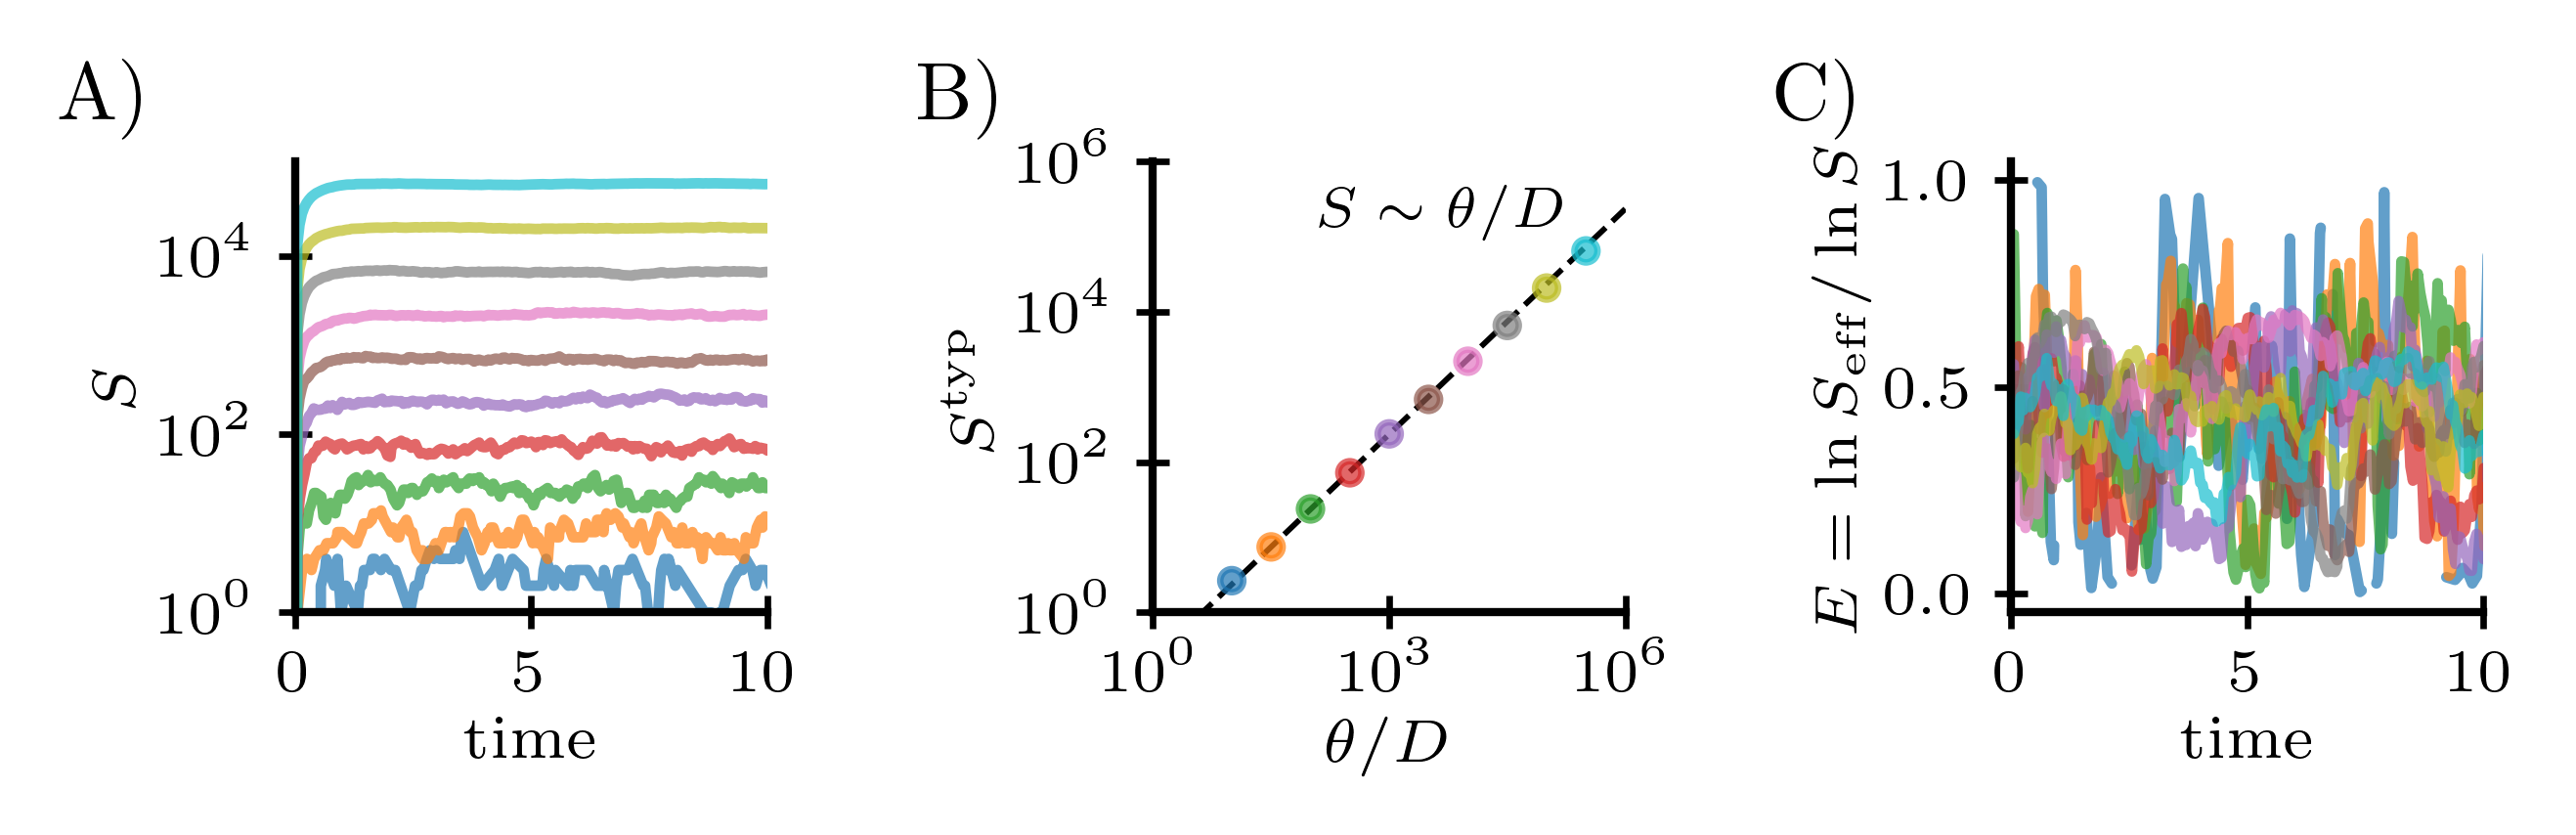

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(4.5, 1.5), layout='tight')
D = 1
gamma = 0.2
alpha = 1.2
typical_richness = []
T_stars = []
for ratio in ratios:    
    ax[0].plot(results_for_ratio[ratio]['t'], results_for_ratio[ratio]['S'], alpha=0.7)
    ax[2].plot(results_for_ratio[ratio]['t'], np.log(results_for_ratio[ratio]['Seff'])/np.log(results_for_ratio[ratio]['S']), alpha=0.7)
    
    S =  results_for_ratio[ratio]['S']
    typical_richness.append(lib.geometric_mean_after_burn(S))
        
ax[0].set_xlim(0, 10)
ax[0].set_yscale('log')
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$S$')
ax[0].set_ylim(1, None)

ratio_range = np.logspace(0, 6, 100)
ax[1].plot(ratio_range, (typical_richness[1] / ratios[1])*ratio_range , linestyle='--', c='black', lw=0.7, zorder=-2)
ax[1].text(0.35, 0.95, r'$S \sim \theta / D$', transform=ax[1].transAxes, fontsize=7, ha='left',va='top');
ax[1].set_xlabel(r'$\theta / D$')
ax[1].set_ylabel(r'$S^{\mathrm{typ}}$')
ax[1].scatter(ratios, typical_richness, s=8, c=np.asarray(colors), alpha=0.7)
ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_xlim([1, 1e6])
ax[1].set_ylim([1, 1e6])

ax[2].set_xlabel(r'time')
ax[2].set_ylabel(r'$E = \ln S_{\mathrm{eff}}/ \ln S$')
ax[2].set_xlim(0, 10)

for axis, label in zip(ax, ["A)", "B)", "C)"]):
    axis.text(
        -0.5, 1.23,
        label,
        transform=axis.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )

plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_richness_with_recruitment_alpha_1.2.pdf', bbox_inches='tight', dpi=200, transparent=True);

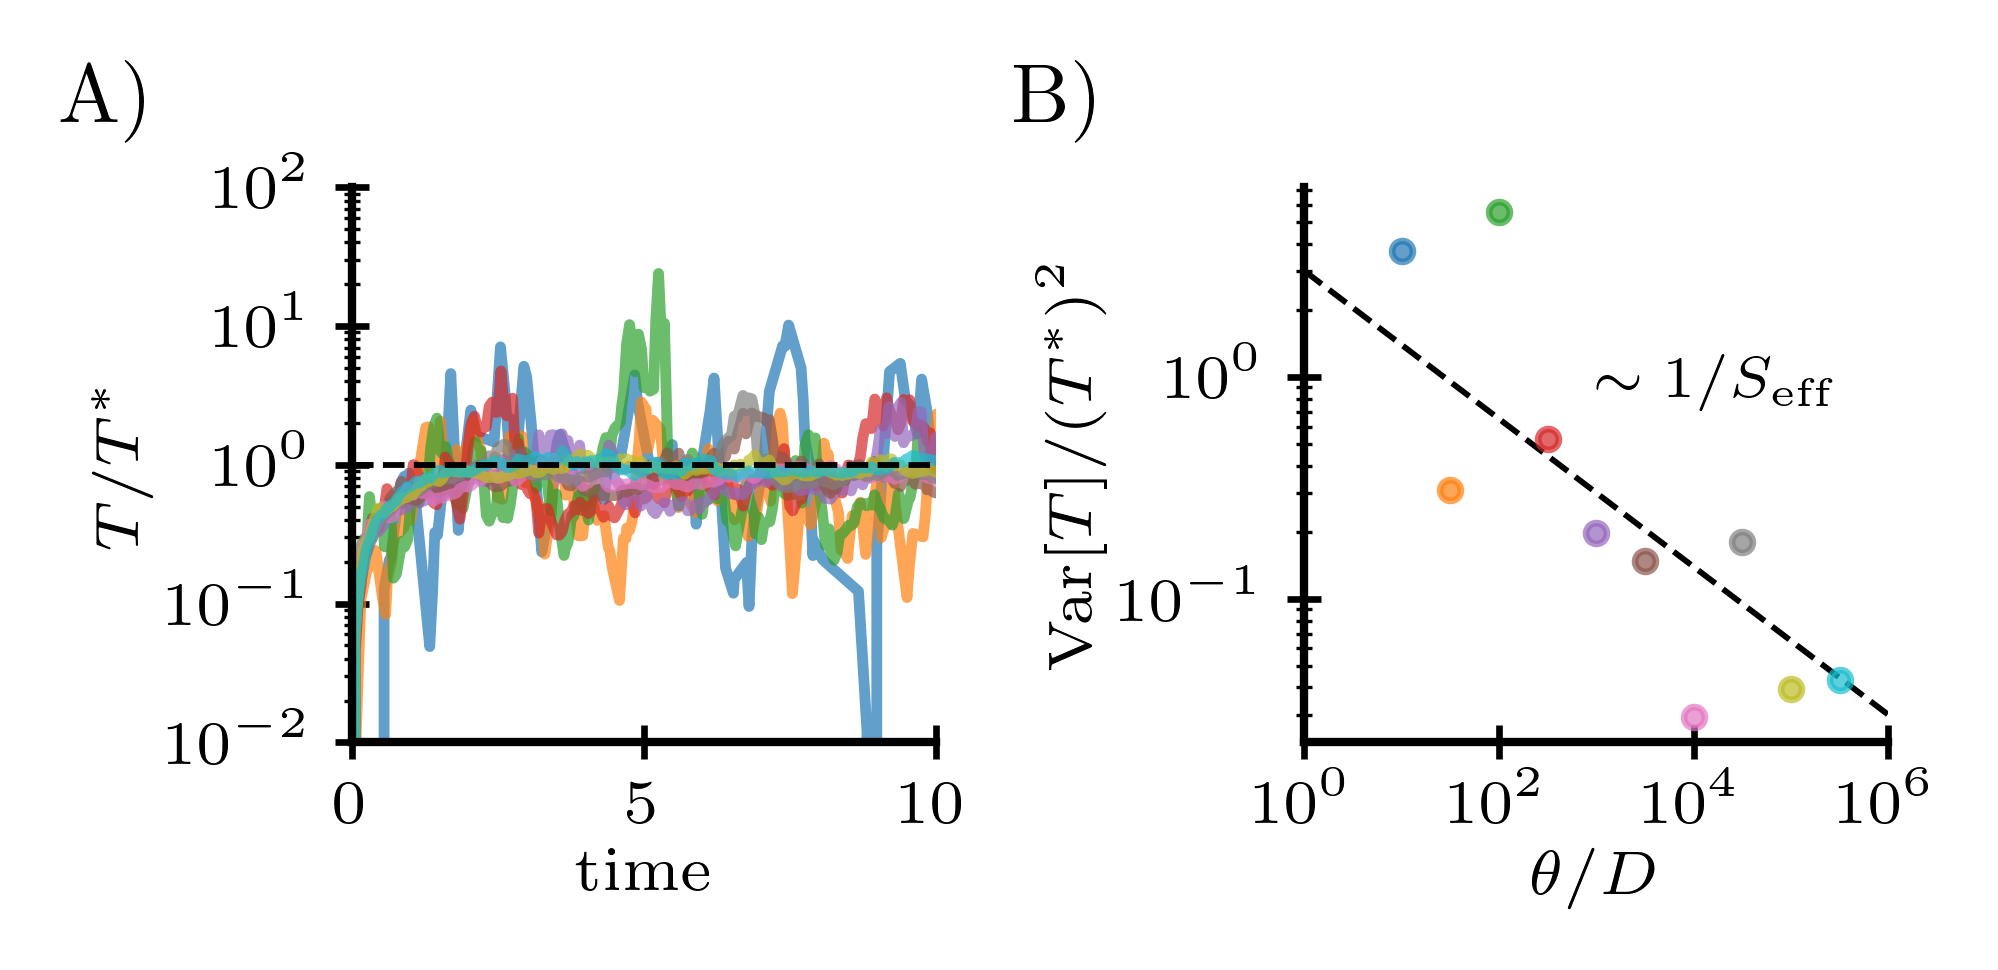

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(3.2, 1.5), layout='constrained')
D = 1
gamma = 0.2
alpha = 1.2
var_Ts= []
for ratio in ratios:
    T_star = ratio / (alpha - 1)  
    T = results_for_ratio[ratio]['T']
    ax[0].plot(results_for_ratio[ratio]['t'], T / T_star, alpha=0.7)
    var_T = np.var(T) / T_star**2
    ax[1].scatter(ratio, var_T, alpha=0.7)
    var_Ts.append(var_T)
    
ax[0].axhline(1, c='black', linestyle='--', lw=0.7)
ax[0].set_yscale('log')
ax[0].set_xlim(0, 10)
ax[0].set_ylim(1e-2, 1e2)
ax[0].set_xlabel(r'time')
ax[0].set_ylabel(r'$T / T^*$')
 
ax[1].set_xlabel(r'$\theta / D$')
ax[1].set_ylabel(r'$\mathrm{Var}[T] / (T^*)^2$')
ax[1].text(0.5, 0.7, r'$\sim 1/S_{\mathrm{eff}}$', transform=ax[1].transAxes, fontsize=7, ha='left',va='top')
ratio_range = np.logspace(0, 6, 100)
prefactor = lib.fit_power_law_prefactor(ratios, var_Ts, (2 * (1 - alpha) / alpha))
ax[1].plot(ratio_range, prefactor * ratio_range ** (2 * (1 - alpha) / alpha), linestyle='--', c='black', lw=0.7, zorder=-2) 
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1, 1e6])

for axis, label in zip(ax, ["A)", "B)"]):
    axis.text(
        -0.5, 1.23,
        label,
        transform=axis.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="top",
        clip_on=False,
    )

### Scaling of diversity for changing $\alpha$

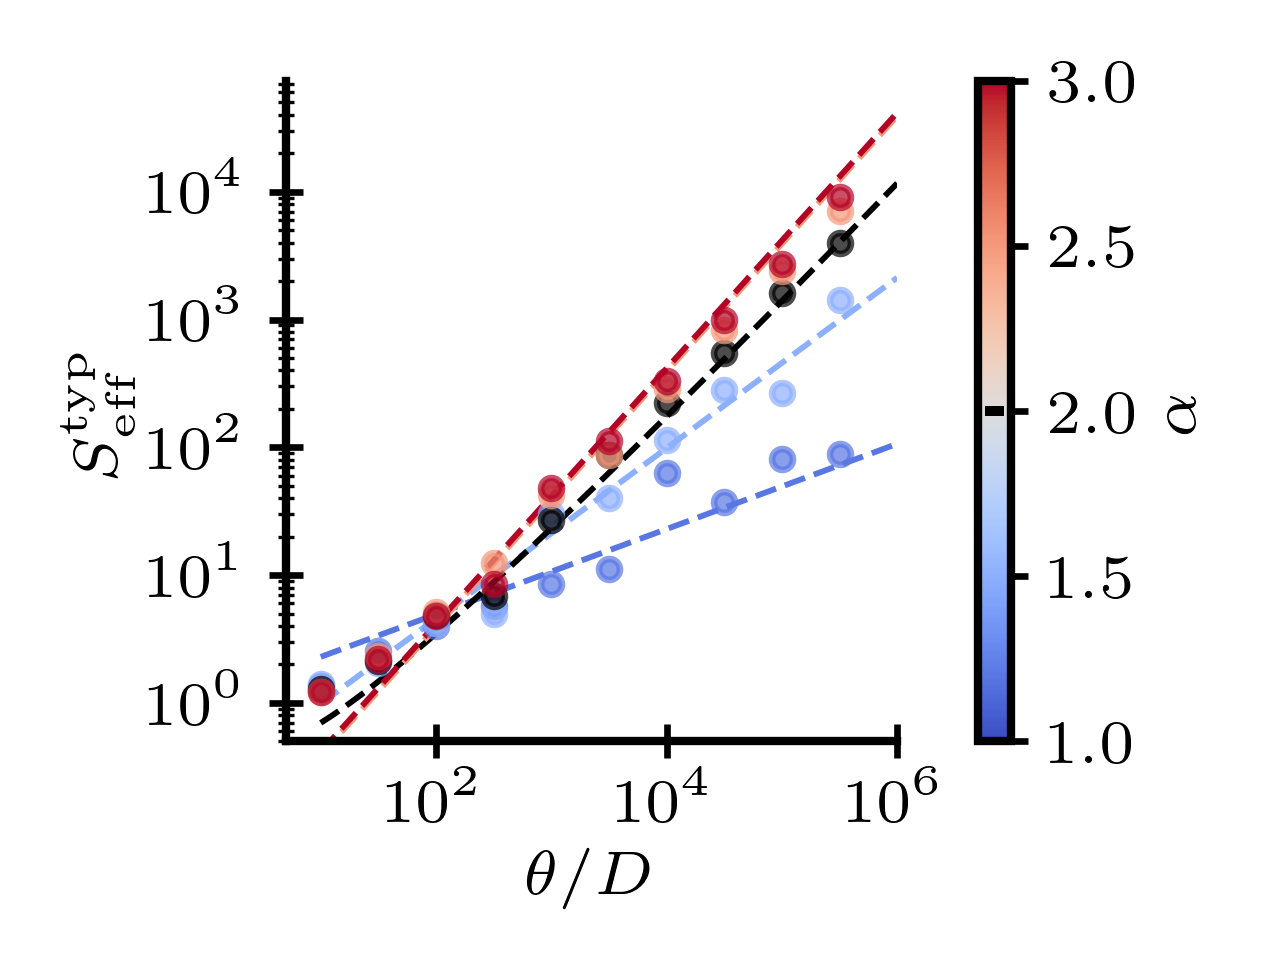

In [9]:
fig, ax = plt.subplots(figsize=(2, 1.5), layout='constrained')

ratios = np.logspace(1, 5.5, 10)
alphas = [1.2, 1.5, 2, 2.5, 3]
cmap_alphas = plt.get_cmap("coolwarm")
norm_alphas = TwoSlopeNorm(vmin=1, vcenter=2, vmax=3)
def alpha_colour(alpha):
    
    if np.isclose(alpha, 2):
        return "black"
    
    return cmap_alphas(norm_alphas(alpha))

for alpha in alphas:
    typical_diversities = []
    for ratio in ratios:
        
        records = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/alpha_{alpha}/ratio_{ratio}.npz", allow_pickle=True)
        t = records['t']
        c_t = records['c']
        
        Seff = np.zeros(len(t))
        for i, time in enumerate(t):
            Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        typical_diversities.append(lib.geometric_mean_after_burn(Seff))
        
    colour = alpha_colour(alpha)
        
    ax.scatter(ratios, typical_diversities, alpha=0.7, color=colour,)
    ratio_range = np.logspace(1, 6, 100)
    if alpha < 2:
        exponent = 2 * (alpha - 1) / alpha
        prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, exponent)
        ax.plot(ratio_range, prefactor*ratio_range**exponent, linestyle='--', lw=0.7, zorder=-2, color=colour)
    
    if alpha > 2:
        prefactor = lib.fit_power_law_prefactor(ratios, typical_diversities, 1)
        ax.plot(ratio_range, prefactor*ratio_range, linestyle='--', lw=0.7, zorder=-2, color=colour)
        
    if alpha == 2:
        z =  ratios / np.log(ratios)
        prefactor = np.sum(z * typical_diversities) / np.sum(z * z)
        ax.plot(ratio_range, prefactor*ratio_range / np.log(ratio_range), linestyle='--', lw=0.7, zorder=-2, color=colour)
        
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([5, 1e6])
ax.set_ylim([0.5, None]);
ax.set_xlabel(r'$\theta / D$')
ax.set_ylabel(r'$S_{\mathrm{eff}}^{\mathrm{typ}}$')

sm = plt.cm.ScalarMappable(norm=norm_alphas, cmap=cmap_alphas)
cbar = fig.colorbar(sm, ax=ax, label=r"$\alpha$")
cbar.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar.ax.get_yaxis_transform(), clip_on=False)

plt.savefig('../../figures/how_to_maintain_diversity/scaling_of_diversity_with_recruitment.pdf', bbox_inches='tight', dpi=200, transparent=True);

## Distribution of the largest clones

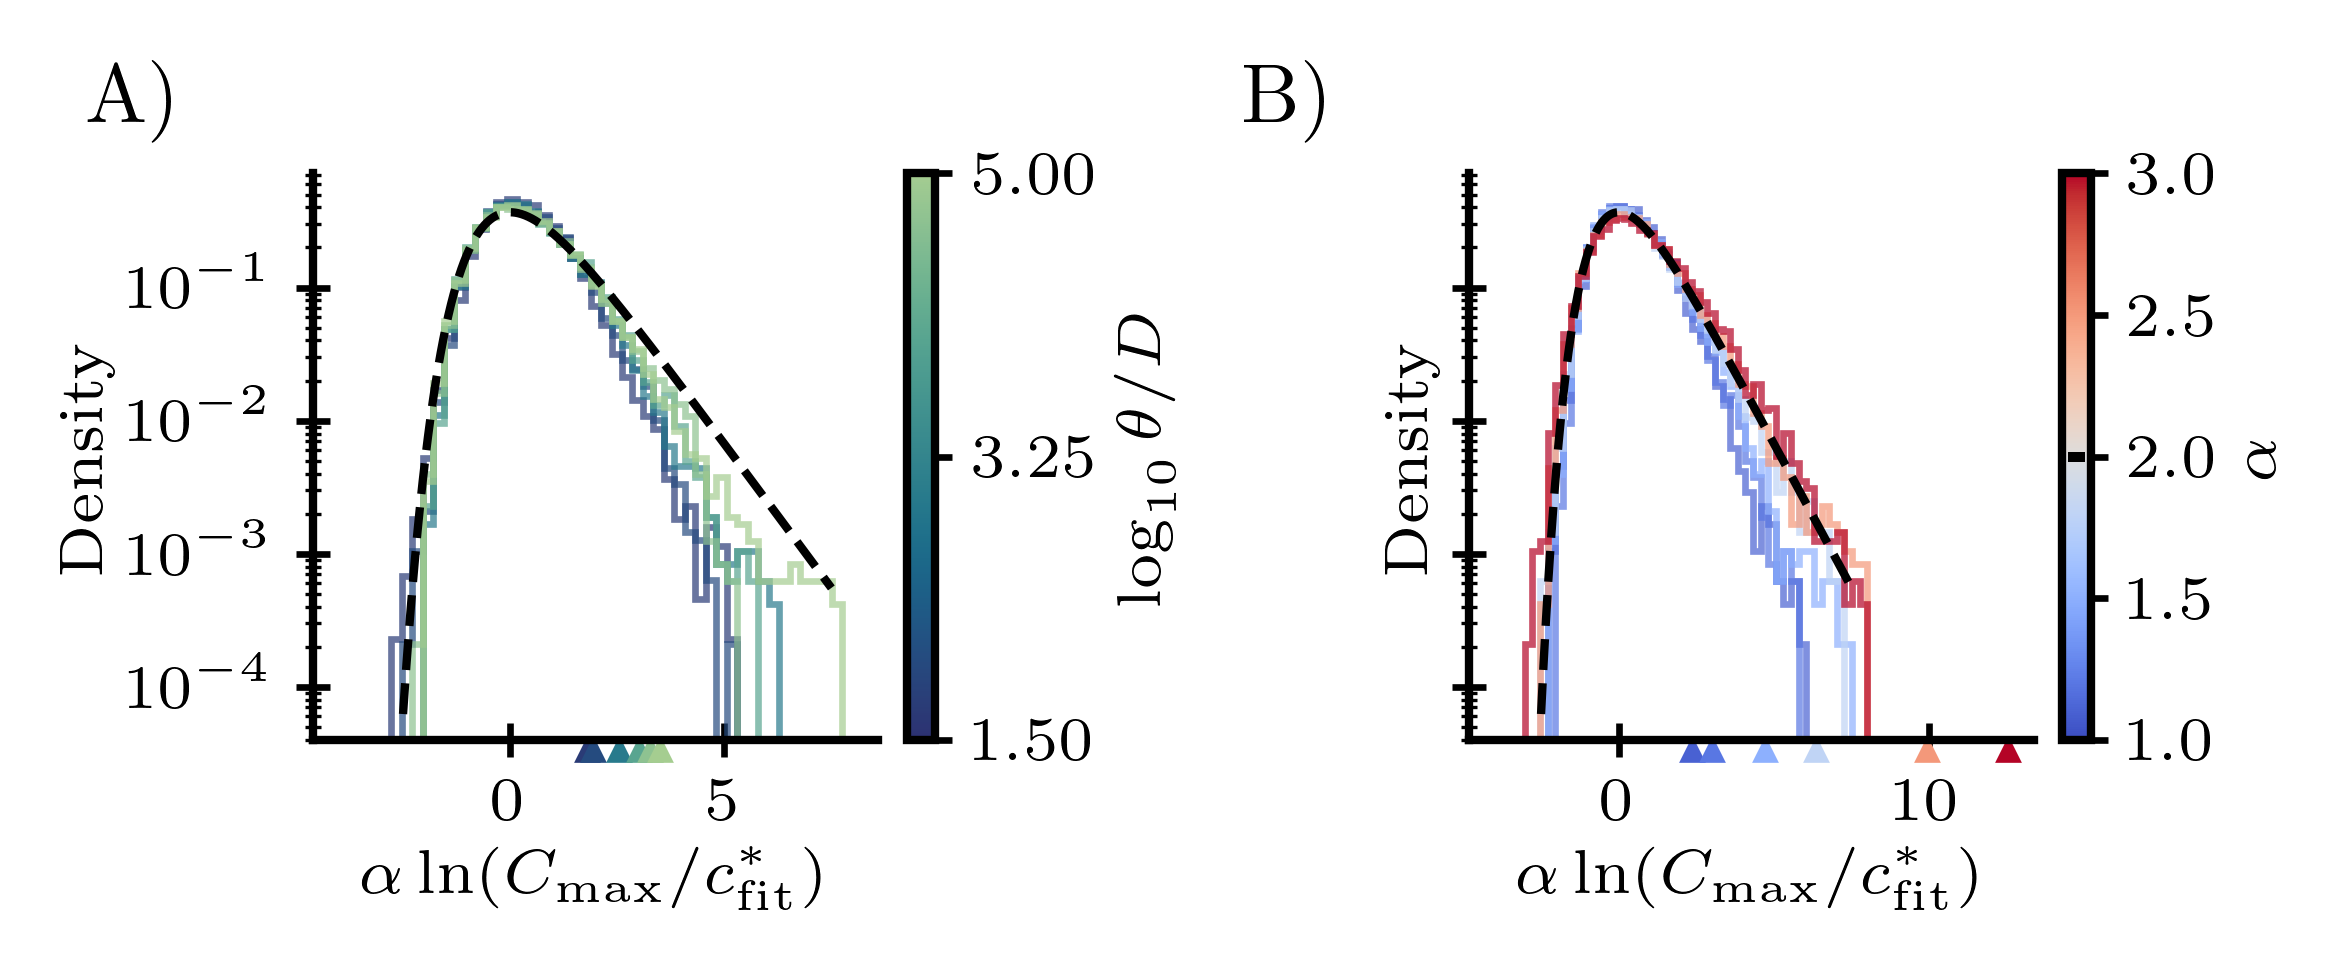

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(3.8, 1.5), layout='constrained', sharey=True)
g_bins = np.linspace(-4, 8, 50)

#Plot for different ratios
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    g, c_star = lib_div.get_g_from_cmax_mean_field(record_long_term['c'], alpha, burn_frac=0.02, return_c_star=True)
    ax[0].hist(g ,density=True, histtype="step", bins=g_bins, alpha=0.7, color=cmap_ratios(norm_ratios(ratio)))
    
    T_star = lib_div.T_star_mean_field(alpha=alpha, theta=10**ratio, D=1)
    g_T_star = alpha * np.log(T_star / c_star)
    ax[0].plot(g_T_star, -0.02, marker='^', markersize=2, color=cmap_ratios(norm_ratios(ratio)),
               transform=ax[0].get_xaxis_transform(),clip_on=False)
        
alphas = [1.1, 1.2, 1.5, 1.8, 2.5, 3]
ratio = 1e4
for alpha in alphas:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{alpha}_theta_4.0.npz", allow_pickle=True)
    
    g, c_star = lib_div.get_g_from_cmax_mean_field(record_long_term['c'], alpha, burn_frac=0.02, return_c_star=True)
    ax[1].hist(g ,density=True, histtype="step", bins=g_bins, alpha=0.7, color=alpha_colour(alpha))
    
    T_star = lib_div.T_star_mean_field(alpha=alpha, theta=ratio, D=1)
    g_T_star = alpha * np.log(T_star / c_star)
    ax[1].plot(g_T_star, -0.02, marker='^', markersize=2, color=alpha_colour(alpha),
               transform=ax[1].get_xaxis_transform(), clip_on=False)
        
g_grid = np.linspace(-2.5, 7.5, 500)
for axes in ax:
    axes.plot(g_grid, gumbel_r.pdf(g_grid), linestyle='--', linewidth=1, c='black')
    axes.set_xlabel(r'$\alpha \ln (C_{\max} / c^*_{\mathrm{fit}})$')
    axes.set_ylabel('Density')
    axes.set_yscale('log')
    
sm_1 = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar_1 = fig.colorbar(sm_1, ax=ax[0], label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))

sm_2 = plt.cm.ScalarMappable(norm=norm_alphas, cmap=cmap_alphas)
cbar_2 = fig.colorbar(sm_2, ax=ax[1], label=r"$\alpha$")
cbar_2.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar_2.ax.get_yaxis_transform(), clip_on=False)

for axis, label in zip(ax, ["A)", "B)"]):
    axis.text(-0.4, 1.2, label,  transform=axis.transAxes, fontsize=10, fontweight="bold", ha="left", va="top", clip_on=False)
    
plt.savefig('../../figures/how_to_maintain_diversity/max_clone_size_distribution.pdf', bbox_inches='tight', dpi=200, transparent=True)

### Improving this to account for large clone feedback

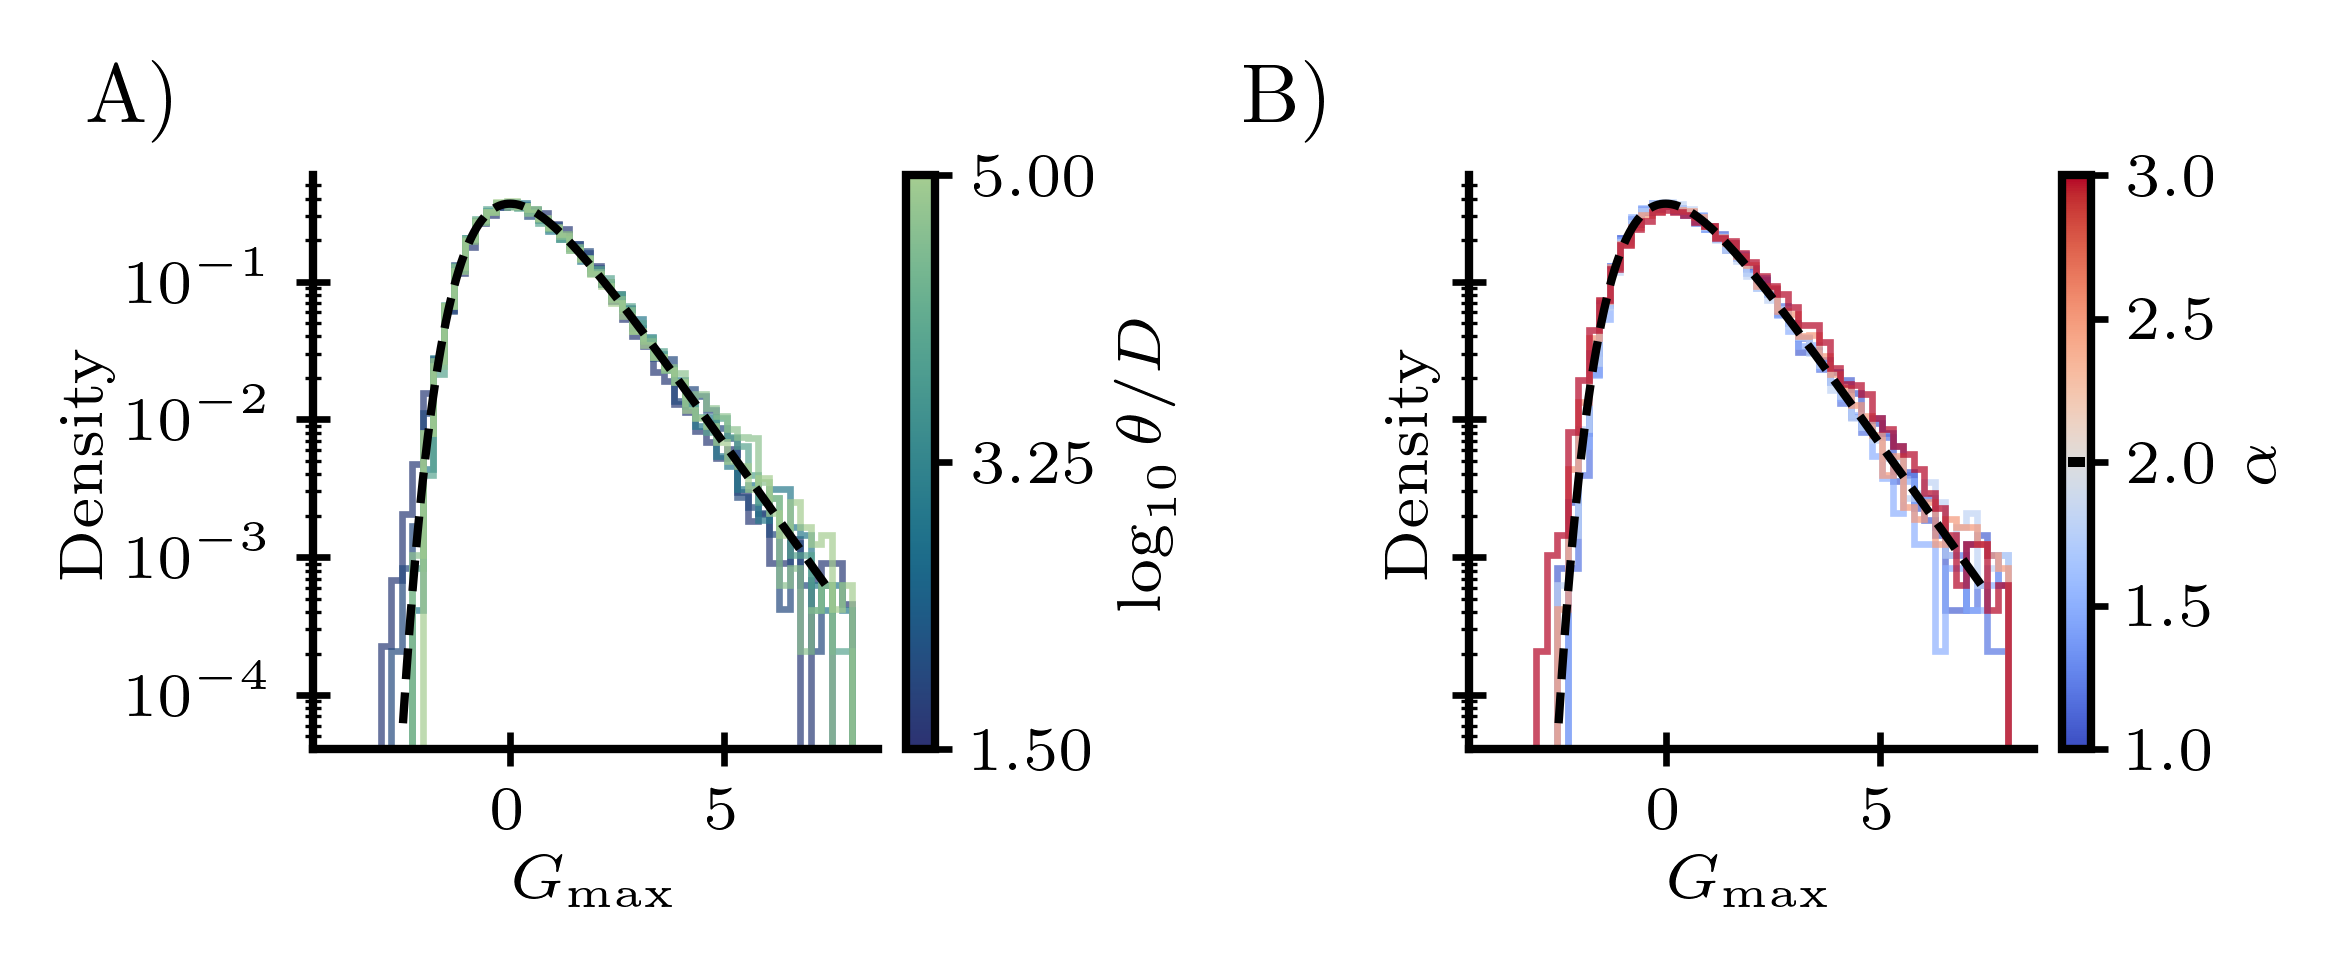

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(3.8, 1.5), layout='constrained', sharey=True)
g_bins = np.linspace(-4, 8, 50)

#Plot for different ratios
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    gamma = alpha - 1
    d = alpha + (alpha - 1) / gamma
    g = lib_div.get_g_from_cmax_cavity_like(record_long_term['c'], alpha, 10**ratio, 1, d, burn_frac=0.02)

    ax[0].hist(g ,density=True, histtype="step", bins=g_bins, alpha=0.7, color=cmap_ratios(norm_ratios(ratio)))
    ax[0].set_ylabel('Density')
    ax[0].set_yscale('log')
        
alphas = [1.1, 1.2, 1.5, 1.8, 2.5, 3]
ratio = 1e4
for alpha in alphas:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{alpha}_theta_4.0.npz", allow_pickle=True)
    
    gamma = alpha - 1
    d = alpha + (alpha - 1) / gamma
    g = lib_div.get_g_from_cmax_cavity_like(record_long_term['c'], alpha, ratio, 1, d, burn_frac=0.02)
       
    ax[1].hist(g ,density=True, histtype="step", bins=g_bins, alpha=0.7, color=alpha_colour(alpha))
    ax[1].set_ylabel('Density')
    ax[1].set_yscale('log')
        
g_grid = np.linspace(-2.5, 7.5, 500)
for axes in ax:
    axes.plot(g_grid, gumbel_r.pdf(g_grid), linestyle='--', linewidth=1, c='black')
    axes.set_xlabel(r'$G_{\max}$')
    
sm_1 = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar_1 = fig.colorbar(sm_1, ax=ax[0], label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))

sm_2 = plt.cm.ScalarMappable(norm=norm_alphas, cmap=cmap_alphas)
cbar_2 = fig.colorbar(sm_2, ax=ax[1], label=r"$\alpha$")
cbar_2.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar_2.ax.get_yaxis_transform(), clip_on=False)

for axis, label in zip(ax, ["A)", "B)"]):
    axis.text(-0.4, 1.2, label,  transform=axis.transAxes, fontsize=10, fontweight="bold", ha="left", va="top", clip_on=False)
    
plt.savefig('../../figures/how_to_maintain_diversity/max_clone_size_distribution_cavity_like.pdf', bbox_inches='tight', dpi=200, transparent=True)

## Diversity fluctuations

### Typical fluctuations in diversity

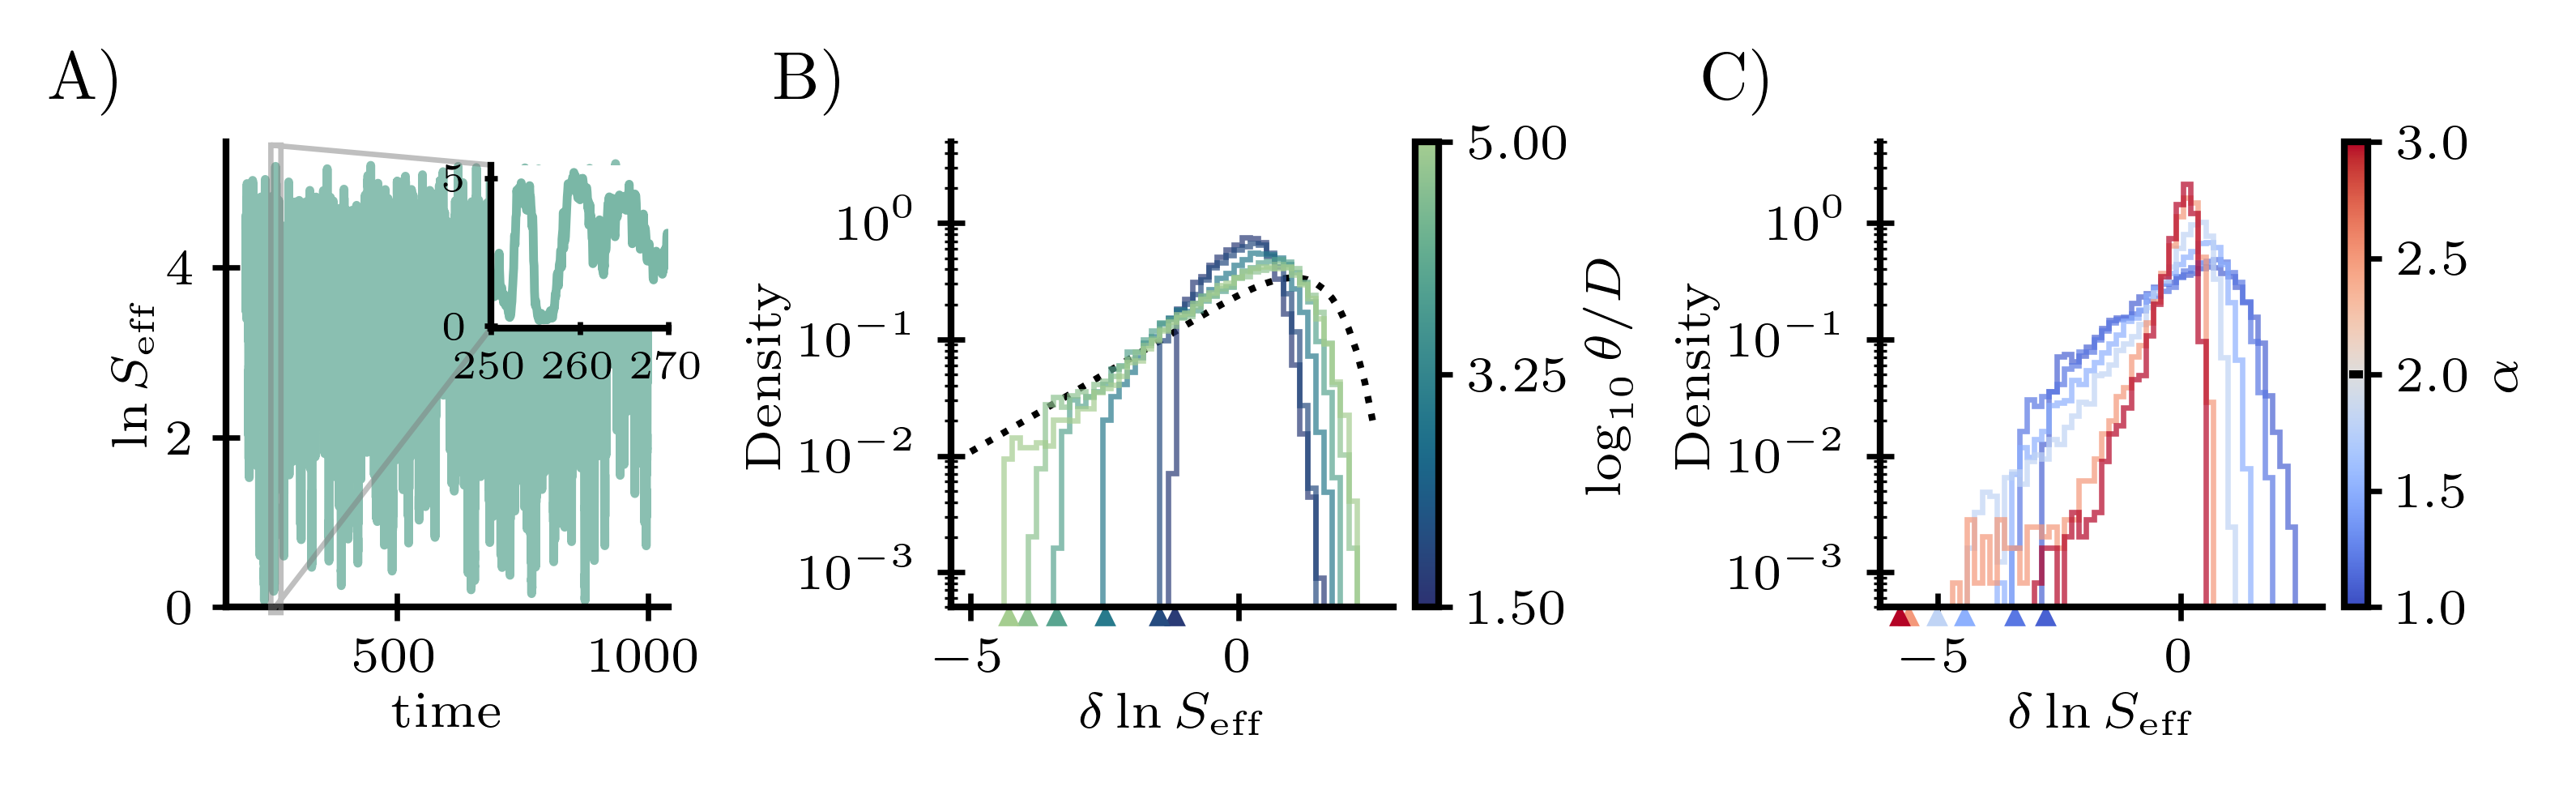

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(5.2, 1.5), layout='constrained', sharey=False)
delta_logSeff_bins = np.linspace(-5, 2.5, 50)

#Plot for different ratios
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        
    burn = int(len(t) * 0.2)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)
    
    if ratio == 4.0:
        ax[0].plot(t, logSeff, alpha=0.7, color=cmap_ratios(norm_ratios(ratio)))
        t0, window = 250, 20
        m = (t >= t0) & (t <= t0 + window)
        axins = ax[0].inset_axes([0.6, 0.6, 0.4, 0.35])
        axins.plot(t[m], logSeff[m], alpha=0.8, color=cmap_ratios(norm_ratios(ratio)))
        axins.set_xlim(t0, t0 + window)
        ax[0].indicate_inset_zoom(axins)
        axins.tick_params(labelsize=6, length=2)
        ax[0].set_ylim(0, None)
    
    ax[1].hist(delta_logSeff ,density=True, histtype="step", bins=delta_logSeff_bins, alpha=0.7, color=cmap_ratios(norm_ratios(ratio)))
    
    ax[1].plot(-np.mean(logSeff), -0.02, marker='^', markersize=2, color=cmap_ratios(norm_ratios(ratio)), transform=ax[1].get_xaxis_transform(),
               clip_on=False)
        
theory_density = lib_div.diversity_fluctuation_density(delta_logSeff_bins, alpha=1.2)
ax[1].plot(delta_logSeff_bins, theory_density, linestyle=":", linewidth=1, color='black', zorder=-5)

alphas = [1.1, 1.2, 1.5, 1.8, 2.5, 3]
ratio = 1e4
for alpha in alphas:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{alpha}_theta_4.0.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
    
    burn = int(len(t) * 0.2)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)
    
    ax[2].hist(delta_logSeff ,density=True, histtype="step", bins=delta_logSeff_bins, alpha=0.7, color=alpha_colour(alpha))
    
    ax[2].plot(-np.mean(logSeff), -0.02, marker='^', markersize=2, color=alpha_colour(alpha), transform=ax[2].get_xaxis_transform(),
               clip_on=False)
        
ax[0].set_xlabel(r'time')      
ax[0].set_ylabel(r'$\ln S_{\mathrm{eff}}$')
for axes in ax[1:]:
    axes.set_xlabel(r'$\delta \ln S_{\mathrm{eff}}$')
    axes.set_ylim(5e-4, 5e0)
    axes.set_ylabel('Density')
    axes.set_yscale('log')
    
sm_1 = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar_1 = fig.colorbar(sm_1, ax=ax[1], label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))

sm_2 = plt.cm.ScalarMappable(norm=norm_alphas, cmap=cmap_alphas)
cbar_2 = fig.colorbar(sm_2, ax=ax[2], label=r"$\alpha$")
cbar_2.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar_2.ax.get_yaxis_transform(), clip_on=False)

for axis, label in zip(ax, ["A)", "B)", "C)"]):
    axis.text(-0.4, 1.2, label,  transform=axis.transAxes, fontsize=10, fontweight="bold", ha="left", va="top", clip_on=False)
    
plt.savefig('../../figures/how_to_maintain_diversity/diversity_fluctuations.pdf', bbox_inches='tight', dpi=200, transparent=False)

#### Attempting to fit the scaling 

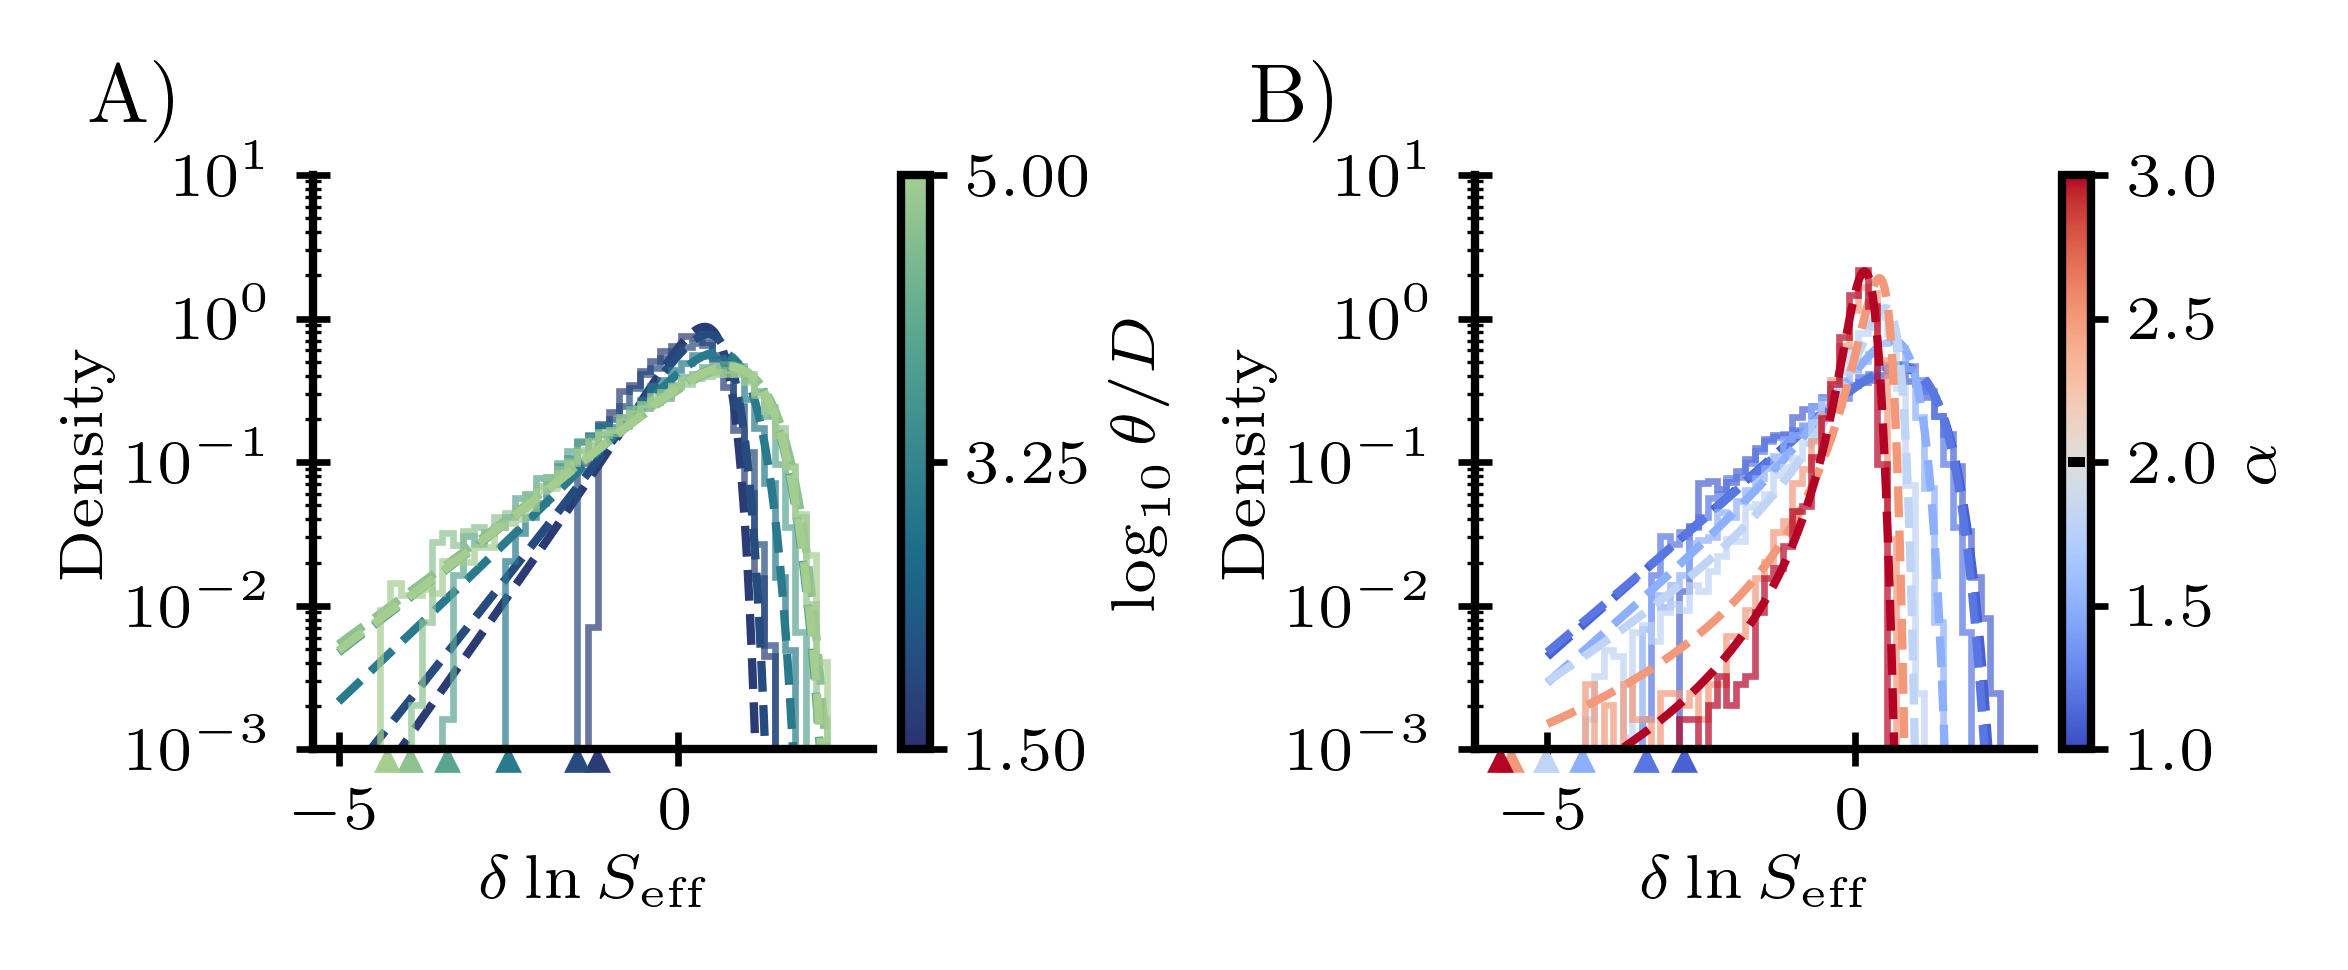

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(3.8, 1.5), layout='constrained', sharey=False)
delta_logSeff_bins = np.linspace(-5, 2.5, 50)
theory_x = np.linspace(-5, 2.5, 500)

#Plot for different ratios
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        
    burn = int(len(t) * 0.2)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)

    ax[0].hist(delta_logSeff ,density=True, histtype="step", bins=delta_logSeff_bins, alpha=0.7, color=cmap_ratios(norm_ratios(ratio)))
    
    ax[0].plot(-np.mean(logSeff), -0.02, marker='^', markersize=2, color=cmap_ratios(norm_ratios(ratio)), transform=ax[0].get_xaxis_transform(),
               clip_on=False)
    
    theory_sample = lib_div.sample_diversity_fluctuations(alpha=1.2)
    A_fit = np.diff(np.quantile(delta_logSeff, [0.2, 0.8]))[0] / np.diff(np.quantile(theory_sample, [0.2, 0.8]))[0]
    theory_density = lib_div.diversity_fluctuation_density(theory_x / A_fit, alpha=1.2) / A_fit
    ax[0].plot(theory_x, theory_density, linestyle="--", linewidth=1, color=cmap_ratios(norm_ratios(ratio)))
        
alphas = [1.1, 1.2, 1.5, 1.8, 2.5, 3]
ratio = 1e4
for alpha in alphas:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_{alpha}_theta_4.0.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
    
    burn = int(len(t) * 0.2)
    t = t[burn:]
    logSeff =  np.log(Seff[burn:])
    delta_logSeff = logSeff - np.mean(logSeff)
    
    ax[1].hist(delta_logSeff ,density=True, histtype="step", bins=delta_logSeff_bins, alpha=0.7, color=alpha_colour(alpha))
    
    ax[1].plot(-np.mean(logSeff), -0.02, marker='^', markersize=2, color=alpha_colour(alpha), transform=ax[1].get_xaxis_transform(),
               clip_on=False)
    
 
    theory_sample = lib_div.sample_diversity_fluctuations(alpha=alpha)
    A_fit = np.diff(np.quantile(delta_logSeff, [0.2, 0.8]))[0] / np.diff(np.quantile(theory_sample, [0.2, 0.8]))[0]
    theory_density = lib_div.diversity_fluctuation_density(theory_x / A_fit, alpha=alpha) / A_fit
    ax[1].plot(theory_x, theory_density, linestyle="--", linewidth=1, color=alpha_colour(alpha))
        

for axes in ax:
    axes.set_xlabel(r'$\delta \ln S_{\mathrm{eff}}$')
    axes.set_ylim(1e-3, 1e1)
    axes.set_ylabel('Density')
    axes.set_yscale('log')
    
sm_1 = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar_1 = fig.colorbar(sm_1, ax=ax[0], label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))

sm_2 = plt.cm.ScalarMappable(norm=norm_alphas, cmap=cmap_alphas)
cbar_2 = fig.colorbar(sm_2, ax=ax[1], label=r"$\alpha$")
cbar_2.ax.plot([0.2, 0.8], [2, 2], color="black", lw=1.2, linestyle="--", transform=cbar_2.ax.get_yaxis_transform(), clip_on=False)

for axis, label in zip(ax, ["A)", "B)"]):
    axis.text(-0.4, 1.2, label,  transform=axis.transAxes, fontsize=10, fontweight="bold", ha="left", va="top", clip_on=False)
    
plt.savefig('../../figures/how_to_maintain_diversity/typical_diversity_fluctuation_scaling.pdf', bbox_inches='tight', dpi=200, transparent=False)

## Fluctuations down to low diversities 

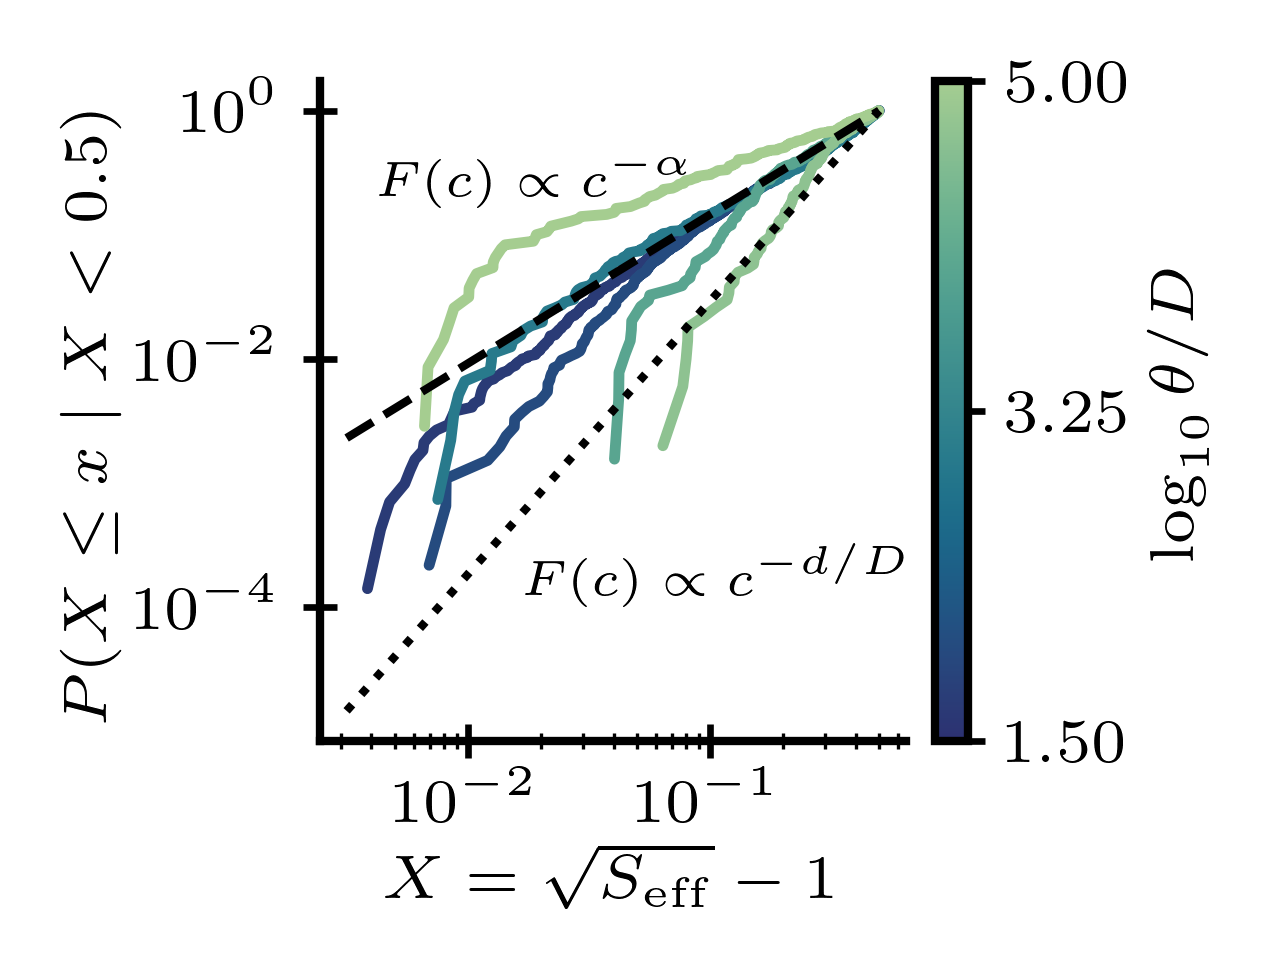

In [22]:
fig, ax = plt.subplots( figsize=(2, 1.5), layout='constrained')

#Plot for different ratios
threshold = 0.5
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        
    burn = int(len(t) * 0.2)
    t = t[burn:]
    X = np.sqrt(Seff[burn:]) - 1
    tail_x, tail_probability = lib.conditional_tail_cdf(X, 'lower', threshold=threshold)
    
    ax.plot(tail_x, tail_probability, color=cmap_ratios(norm_ratios(ratio)))
    
xs_to_plot = np.logspace(-2.5, np.log10(threshold), 100)
ax.plot(xs_to_plot, (xs_to_plot/threshold)**(alpha), color='black', linestyle='--', linewidth=1)

d = (alpha + (alpha - 1) / (alpha - 1))
ax.plot(xs_to_plot, (xs_to_plot/threshold)**(d), color='black', linestyle=':', linewidth=1)
            
ax.set_xlabel(r'$X = \sqrt{S_{\mathrm{eff}}} - 1$')
ax.set_ylabel(rf'$P(X \leq x \mid X < {threshold})$')
ax.set_yscale('log')
ax.set_xscale('log')

ax.text(0.1, 0.9, r'$F(c) \propto c^{-\alpha}$', transform=ax.transAxes, fontsize=6, ha='left',va='top')
ax.text(0.35, 0.3, r'$F(c) \propto c^{-d/D}$', transform=ax.transAxes, fontsize=6, ha='left',va='top')
    
sm = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar = fig.colorbar(sm, ax=ax, label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))
plt.savefig('../../figures/how_to_maintain_diversity/large_diversity_fluctuation_scaling.pdf', bbox_inches='tight', dpi=200, transparent=False)

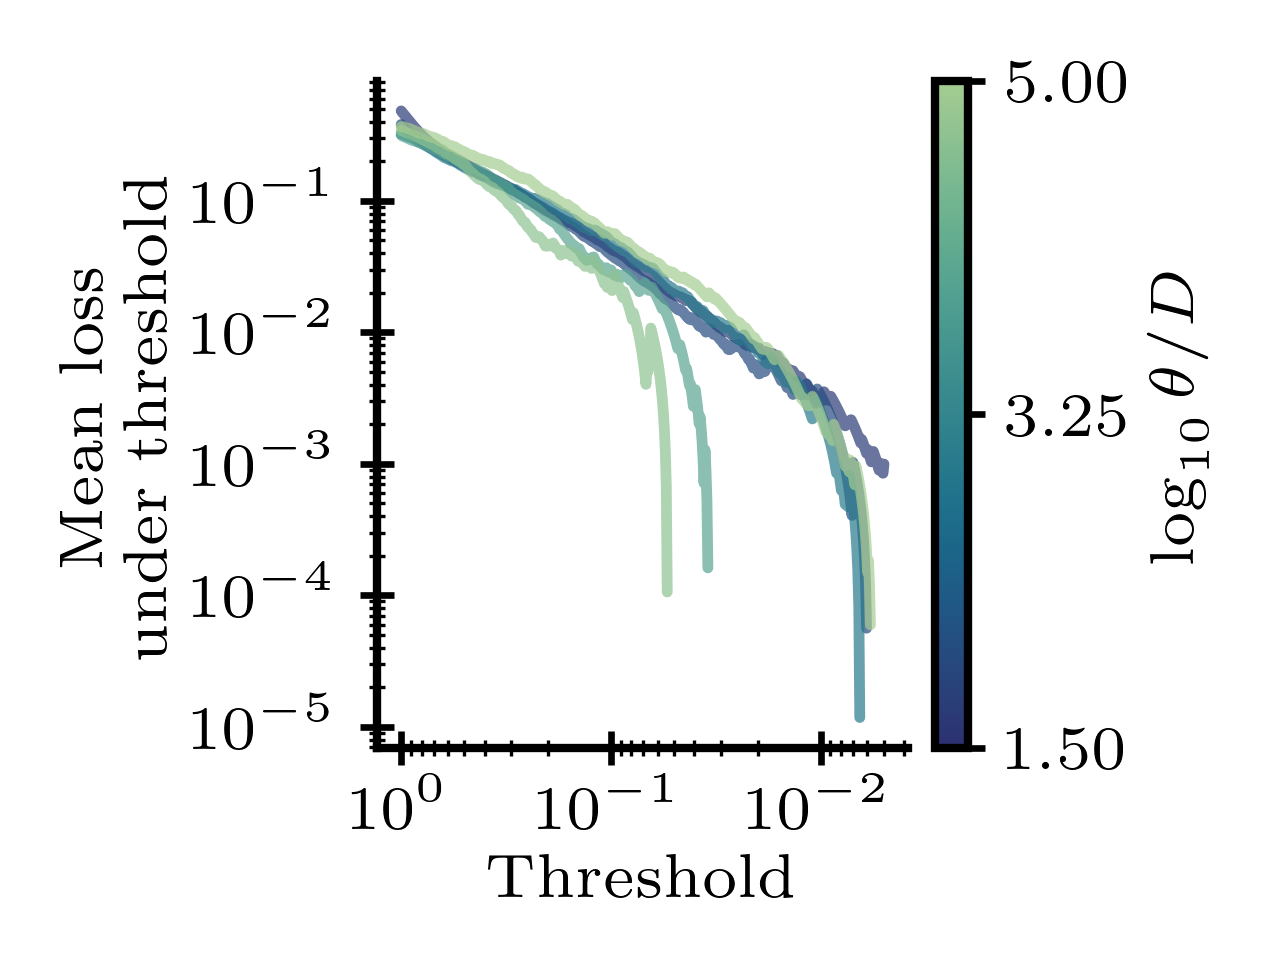

In [15]:
fig, ax = plt.subplots( figsize=(2, 1.5), layout='constrained')

#Plot for different ratios
thresholds = np.logspace(np.log10(0.005), 0, 500)
ratios = [1.7, 2.0, 3.0, 4.0, 4.7, 5.0]
alpha = 1.2
cmap_ratios = sns.color_palette("crest_r", as_cmap=True)
norm_ratios = mpl.colors.Normalize(vmin=1.5, vmax=5)
for ratio in ratios:
    record_long_term = np.load(DATA_PATH + f"how_to_maintain_diversity/source_of_clones/long_time_sims/alpha_1.2_theta_{ratio}.npz", allow_pickle=True)
    
    t = record_long_term['t']
    c_t = record_long_term['c']
    Seff = np.zeros(len(t))
    S = np.zeros(len(t))
    for i, time in enumerate(t):
        Seff[i] = lib.get_average_simpsons_diversity(c_t[i])
        S[i] = int(np.sum(np.all(c_t[i] > 0.1, axis=1)))
        
    burn = int(len(t) * 0.2)
    t = t[burn:]
    #X = np.sqrt(Seff[burn:]) - 1
    X = np.log10(Seff[burn:])
    mean_under_thresholds = lib.mean_over_threshold(X, thresholds)
    
    ax.plot(thresholds, thresholds - mean_under_thresholds, color=cmap_ratios(norm_ratios(ratio)), alpha=0.7)
    
# xs_to_plot = np.logspace(-2.5, np.log10(threshold), 100)
# ax.plot(xs_to_plot, (xs_to_plot/threshold)**(alpha), color='black', linestyle='--', linewidth=1)

ax.set_xlabel("Threshold")
ax.set_ylabel("Mean loss \n under threshold")
ax.set_yscale('log')
ax.set_xscale('log')
ax.invert_xaxis()
    
sm = mpl.cm.ScalarMappable(norm=norm_ratios, cmap=cmap_ratios)
cbar = fig.colorbar(sm, ax=ax, label=r"$\log_{10} \theta/D$", ticks=np.linspace(1.5, 5, 3))
#plt.savefig('../../figures/how_to_maintain_diversity/large_diversity_fluctuation_scaling.pdf', bbox_inches='tight', dpi=200, transparent=False)